<a href="https://colab.research.google.com/github/nkefeyan-22-26/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Lab16/Lab%2016%3A%20High%20Dimensional%20GDP%20Growth%20Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Objective: Forecast GDP Growth with Regularized Regression
You are an economist at the World Bank. Your team needs to forecast 5-year average GDP per capita growth rates for 120+ countries using 50+ development indicators drawn from the World Development Indicators (WDI). With so many predictors and limited country-level observations, Ordinary Least Squares (OLS) will overfit badly. In this lab, you will demonstrate OLS failure in high dimensions, then apply Lasso and Ridge regularization to find the most informative predictors. By the end, you will be able to:

*   Demonstrate the OLS failure mode (overfitting) on a high-dimensional dataset
*   Implement LassoCV and RidgeCV using a proper sklearn Pipeline with standardization
*   Visualize and interpret the Lasso Path — identifying which indicators Lasso selects first
*   Critically distinguish between predictive redundancy and economic irrelevance

Data source: World Bank World Development Indicators (WDI) via wbgapi

Key packages: wbgapi, scikit-learn, matplotlib, numpy, pandas

In [2]:
# ============================================================
# SETUP — Run this cell first
# ============================================================

# Uncomment and run once if packages are missing:
!pip install wbgapi scikit-learn matplotlib seaborn numpy pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import wbgapi as wb

# Reproducibility
np.random.seed(42)

print("Setup complete ✓")

Setup complete ✓


We define a dictionary of 35+ WDI indicator codes spanning trade, macroeconomics, education, infrastructure, health, finance, natural resources, agriculture, and governance. These are the same indicators IMF and World Bank economists use in growth diagnostics. We download 7 years of data (2013–2019, pre-COVID) via the WDI API.

In [3]:
# ============================================================
# PART 1A: Download World Bank Data
# ============================================================

# WDI indicator codes for our predictors
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),  # 2013–2019
        skipBlanks=True,
        labels=False
    )
    raw_data.columns = [INDICATORS[c] if c in INDICATORS else c for c in raw_data.columns]
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (7255, 7)
Download successful ✓


We average all indicators across the 2013–2019 period for each country, producing a single cross-sectional observation per country. Countries with more than 40% missing values are dropped. Remaining gaps are filled with the cross-country median — a standard approach in cross-country empirics that avoids the selection bias of listwise deletion.

In [4]:
# ============================================================
# PART 1B: Build the Analysis Dataset
# ============================================================

# Average over time dimension
if isinstance(raw_data.index, pd.MultiIndex):
    averaged_by_series = raw_data.mean(axis=1)
    country_data = averaged_by_series.unstack(level='series')
    country_data = country_data.rename(columns=INDICATORS)
else:
    country_data = raw_data.copy()

# Drop countries with too many missing values (keep countries with >= 60% non-missing)
threshold = 0.60
country_data = country_data.dropna(thresh=int(threshold * country_data.shape[1]))

# Drop indicators with too many missing values across countries
country_data = country_data.dropna(axis=1, thresh=int(threshold * len(country_data)))

# Final fill: impute remaining missing values with the cross-country median
country_data = country_data.fillna(country_data.median())

print(f"Final dataset: {len(country_data)} countries × {country_data.shape[1]} indicators")
print(f"\nSample countries: {list(country_data.index[:5])}")
print(f"\nIndicators retained: {list(country_data.columns)}")
print(f"\nGDP growth summary:")
print(country_data[OUTCOME_VAR].describe().round(2))

Final dataset: 238 countries × 29 indicators

Sample countries: ['ABW', 'AFE', 'AFG', 'AFW', 'AGO']

Indicators retained: ['arable_land_pct', 'current_account_pct_gdp', 'royalties_receipts', 'fdi_inflows_pct_gdp', 'electricity_access_pct', 'renewable_energy_pct', 'atms_per100k', 'private_credit_pct_gdp', 'inflation_cpi', 'real_interest_rate', 'govt_expenditure_pct_gdp', 'mobile_subscriptions_per100', 'internet_users_pct', 'trade_pct_gdp', 'agriculture_pct_gdp', 'gdp_growth_pc', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'adult_literacy_rate', 'secondary_enrollment_gross', 'tertiary_enrollment_gross', 'education_expenditure_pct_gdp', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'unemployment_rate', 'life_expectancy', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']

GDP growth summary:
count    238.00
mean       1.76
std        2.45
min      -12.55
25%        0.57
50%        1.80
75%        3.30
max        7.39
Name: gdp_growth_pc, dtype: float64

We split countries (not time periods) into training and test sets — a 70/30 split. This simulates the realistic challenge an IMF forecaster faces: can the model generalize to countries it has never seen? Features are standardized to zero mean and unit variance, which is critical for Ridge and Lasso since these methods penalize coefficient magnitude.

In [5]:
# ============================================================
# PART 1C: Train-Test Split & OLS Baseline
# ============================================================

# Separate outcome (y) from predictors (X)
feature_cols = [c for c in country_data.columns if c != OUTCOME_VAR]

X = country_data[feature_cols].values
y = country_data[OUTCOME_VAR].values
feature_names = feature_cols

# 70/30 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"Training countries: {X_train.shape[0]}")
print(f"Test countries: {X_test.shape[0]}")
print(f"Number of predictors: {X_train.shape[1]}")
print(f"Predictor-to-observation ratio (train): p/n = {X_train.shape[1]}/{X_train.shape[0]} = {X_train.shape[1]/X_train.shape[0]:.2f}")
print()
print("If p/n > 0.5, OLS is at serious risk of overfitting.")

# Standardize features (critical for Ridge and Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only!
X_test_scaled  = scaler.transform(X_test)         # apply same transform to test

print("\nFeatures standardized (zero mean, unit variance) ✓")

Training countries: 166
Test countries: 72
Number of predictors: 28
Predictor-to-observation ratio (train): p/n = 28/166 = 0.17

If p/n > 0.5, OLS is at serious risk of overfitting.

Features standardized (zero mean, unit variance) ✓


OLS will overfit when p/n is large. We predict this **before** looking at results: expect high training R² but much lower (possibly negative) test R². OLS assigns non-zero coefficients to every single predictor — even variables unlikely to drive growth — because it has no mechanism to say “this variable adds noise, not signal.”

In [6]:
# ============================================================
# PART 1D: OLS Baseline — Demonstrating the Failure Mode
# ============================================================

ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

# Training performance
y_train_pred_ols = ols_model.predict(X_train_scaled)
ols_train_r2  = r2_score(y_train, y_train_pred_ols)
ols_train_mse = mean_squared_error(y_train, y_train_pred_ols)

# Test performance
y_test_pred_ols = ols_model.predict(X_test_scaled)
ols_test_r2  = r2_score(y_test, y_test_pred_ols)
ols_test_mse = mean_squared_error(y_test, y_test_pred_ols)

print("=" * 45)
print("OLS BASELINE RESULTS")
print("=" * 45)
print(f"Training R²:  {ols_train_r2:.3f}")
print(f"Test R²:      {ols_test_r2:.3f}")
print(f"")
print(f"Training MSE: {ols_train_mse:.3f}")
print(f"Test MSE:     {ols_test_mse:.3f}")
print(f"")
print(f"Gap (Train R² - Test R²): {ols_train_r2 - ols_test_r2:.3f}")
print("=" * 45)
print()
print("Interpretation:")
print(f"  OLS fits the training data {ols_train_r2:.0%} — but only explains")
print(f"  {max(ols_test_r2, 0):.0%} of test variance. This is overfitting.")

OLS BASELINE RESULTS
Training R²:  0.600
Test R²:      -0.849

Training MSE: 2.640
Test MSE:     8.252

Gap (Train R² - Test R²): 1.449

Interpretation:
  OLS fits the training data 60% — but only explains
  0% of test variance. This is overfitting.


A large gap between training R² and test R². This is the variance explosion problem: with many predictors relative to observations, OLS memorizes the training data rather than learning generalizable patterns. Notice that OLS assigns non-zero coefficients for every single predictor — it has no mechanism to enforce sparsity. The gap between training R² and test R² (ideally < 0.3) is your key diagnostic.

# Ridge Regression with Cross-Validated Lambda
Ridge adds a squared-magnitude penalty (λ||β||²) to the OLS objective, shrinking all coefficients toward zero but keeping every predictor in the model. RidgeCV tries a grid of λ values and selects the one that minimizes cross-validation error. Note that scikit-learn calls λ “alpha” for historical reasons.



In [7]:
# ============================================================
# PART 2A: Ridge Regression with Cross-Validated Lambda
# ============================================================

# Grid of lambda (alpha) values to try — log-spaced from 0.01 to 1000
lambda_grid = np.logspace(-2, 3, 50)

# TODO: Create a RidgeCV with 5-fold CV and the lambda_grid above
ridge_cv = RidgeCV(alphas=lambda_grid, cv=5)  # ← complete this line

# TODO: Fit ridge_cv on the scaled training data
ridge_cv.fit(X_train_scaled, y_train)  # ← complete this line

# Evaluate on test set
y_test_pred_ridge = ridge_cv.predict(X_test_scaled)
ridge_test_r2  = r2_score(y_test, y_test_pred_ridge)
ridge_test_mse = mean_squared_error(y_test, y_test_pred_ridge)

print("=" * 45)
print("RIDGE REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {ridge_cv.alpha_:.4f}")
print(f"Non-zero coefficients:    {np.sum(ridge_cv.coef_ != 0)} of {X_train.shape[1]}")
print(f"Test R²:                  {ridge_test_r2:.3f}")
print(f"Test MSE:                 {ridge_test_mse:.3f}")
print()
print(f"vs. OLS: Test R² = {ols_test_r2:.3f}, Test MSE = {ols_test_mse:.3f}")

RIDGE REGRESSION RESULTS
Optimal λ* (CV-selected): 47.1487
Non-zero coefficients:    28 of 28
Test R²:                  -0.051
Test MSE:                 4.691

vs. OLS: Test R² = -0.849, Test MSE = 8.252


# LassoCV — Automated Feature Selection
Lasso adds an absolute-value penalty (λ||β||₁) that drives many coefficients to exactly zero, performing automatic feature selection. Complete the fit_lasso_cv() function below, then examine which predictors survive and which are eliminated.



In [8]:
# ============================================================
# PART 2B: LassoCV — Automated Feature Selection
# ============================================================

def fit_lasso_cv(X_train, y_train, X_test, y_test, cv=5):
    """
    Fit LassoCV to select optimal regularization parameter
    and evaluate on test set.

    Parameters
    ----------
    X_train : np.ndarray — Standardized training features
    y_train : np.ndarray — Training outcome (GDP growth)
    X_test  : np.ndarray — Standardized test features
    y_test  : np.ndarray — Test outcome
    cv      : int — Number of cross-validation folds

    Returns
    -------
    lasso_model : LassoCV — Fitted model with optimal alpha
    test_r2     : float   — R² on held-out test set
    test_mse    : float   — MSE on held-out test set
    """
    # TODO: Create a LassoCV with cv folds and max_iter=10_000
    lasso_model = LassoCV(cv=cv, max_iter=10_000, random_state=42)

    # TODO: Fit the model on training data
    lasso_model.fit(X_train, y_train)

    # Predict on test set
    y_pred = lasso_model.predict(X_test)

    # TODO: Compute test R² and test MSE
    test_r2  = r2_score(y_test, y_pred)
    test_mse = mean_squared_error(y_test, y_pred)

    return lasso_model, test_r2, test_mse


# Call the function
lasso_cv_model, lasso_test_r2, lasso_test_mse = fit_lasso_cv(
    X_train_scaled, y_train, X_test_scaled, y_test, cv=5
)

n_nonzero = np.sum(lasso_cv_model.coef_ != 0)

print("=" * 45)
print("LASSO REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {lasso_cv_model.alpha_:.4f}")
print(f"Non-zero coefficients:    {n_nonzero} of {X_train.shape[1]}")
print(f"Test R²:                  {lasso_test_r2:.3f}")
print(f"Test MSE:                 {lasso_test_mse:.3f}")
print()
print("Selected predictors (non-zero Lasso coefficients):")
selected_features = [
    (feature_names[i], lasso_cv_model.coef_[i])
    for i in range(len(feature_names))
    if lasso_cv_model.coef_[i] != 0
]
for name, coef in sorted(selected_features, key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:<40} coef = {coef:+.4f}")

LASSO REGRESSION RESULTS
Optimal λ* (CV-selected): 0.0656
Non-zero coefficients:    17 of 28
Test R²:                  -0.330
Test MSE:                 5.934

Selected predictors (non-zero Lasso coefficients):
  inflation_cpi                            coef = -1.0240
  population_growth                        coef = -0.7706
  natural_resource_rents_pct_gdp           coef = -0.6521
  health_expenditure_pct_gdp               coef = -0.4145
  infant_mortality_per1000                 coef = -0.3856
  atms_per100k                             coef = -0.3850
  unemployment_rate                        coef = -0.3716
  renewable_energy_pct                     coef = +0.3627
  urbanization_pct                         coef = -0.3546
  exchange_rate_official                   coef = +0.3112
  arable_land_pct                          coef = +0.1881
  tertiary_enrollment_gross                coef = -0.0797
  mobile_subscriptions_per100              coef = +0.0729
  private_credit_pct_gdp            

The Lasso Path traces all coefficient estimates as λ varies from large (everything zero) to small (approaching OLS). The first variable to enter — the one whose coefficient leaves zero at the highest penalty — is the single strongest predictor of GDP growth. The vertical dashed line marks our CV-selected λ*. Colored lines are the selected predictors; gray lines are those that Lasso zeroed out.



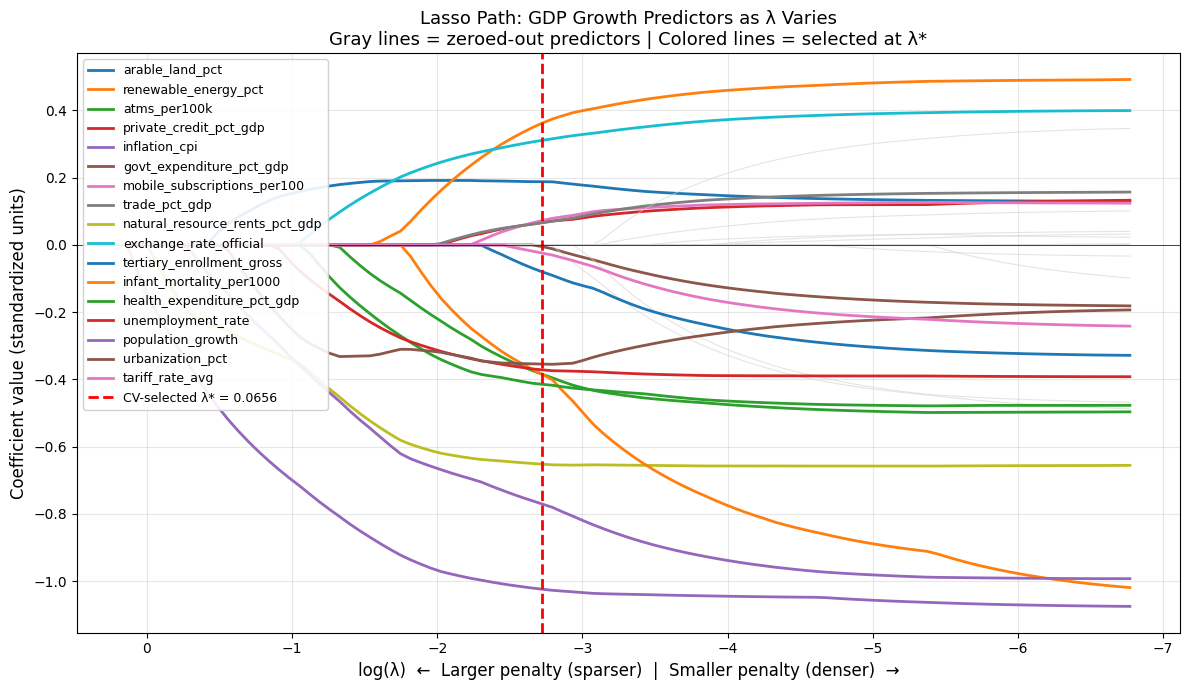

Lasso Path saved to lasso_path_gdp_growth.png


In [9]:
# ============================================================
# PART 2C: The Lasso Path — Who Enters First?
# ============================================================

alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train,
    eps=1e-3,
    n_alphas=100,
)

optimal_alpha = lasso_cv_model.alpha_

fig, ax = plt.subplots(figsize=(12, 7))

active_features_idx = np.where(lasso_cv_model.coef_ != 0)[0]

for i in range(len(feature_names)):
    if i in active_features_idx:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=2, label=feature_names[i])
    else:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=0.8, color='lightgray', alpha=0.6)

ax.axvline(np.log(optimal_alpha), color='red', linestyle='--', linewidth=2,
           label=f'CV-selected λ* = {optimal_alpha:.4f}')
ax.axhline(0, color='black', linewidth=0.5)

ax.set_xlabel('log(λ)  ←  Larger penalty (sparser)  |  Smaller penalty (denser)  →',
               fontsize=12)
ax.set_ylabel('Coefficient value (standardized units)', fontsize=12)
ax.set_title(
    'Lasso Path: GDP Growth Predictors as λ Varies\n'
    'Gray lines = zeroed-out predictors | Colored lines = selected at λ*',
    fontsize=13
)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.invert_xaxis()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lasso_path_gdp_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Lasso Path saved to lasso_path_gdp_growth.png")

# Model Comparison Table
Build a side-by-side comparison of OLS, Ridge, and Lasso. Pay attention to the training R² vs. test R² gap for each method, the number of non-zero predictors, and the test MSE. This table is the core deliverable that demonstrates the bias-variance tradeoff in action.

In [10]:
# ============================================================
# PART 2D: Model Comparison Table
# ============================================================

comparison = pd.DataFrame({
    'Method': ['OLS', 'Ridge (RidgeCV)', 'Lasso (LassoCV)'],
    'Lambda (α*)': [
        'N/A (no penalty)',
        f'{ridge_cv.alpha_:.4f}',
        f'{lasso_cv_model.alpha_:.4f}'
    ],
    'Non-zero Predictors': [
        X_train.shape[1],
        X_train.shape[1],
        np.sum(lasso_cv_model.coef_ != 0)
    ],
    'Training R²': [
        f'{r2_score(y_train, ols_model.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, ridge_cv.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, lasso_cv_model.predict(X_train_scaled)):.3f}'
    ],
    'Test R²': [
        f'{ols_test_r2:.3f}',
        f'{ridge_test_r2:.3f}',
        f'{lasso_test_r2:.3f}'
    ],
    'Test MSE': [
        f'{ols_test_mse:.3f}',
        f'{ridge_test_mse:.3f}',
        f'{lasso_test_mse:.3f}'
    ]
})

print(comparison.to_string(index=False))
print()
print("Key observations:")
print(f"  • OLS training R² >> test R²: evidence of overfitting (high variance)")
print(f"  • Ridge and Lasso reduce the train-test gap")
print(f"  • Lasso selects only {np.sum(lasso_cv_model.coef_ != 0)} of {X_train.shape[1]} predictors")
print(f"  • The other {X_train.shape[1] - np.sum(lasso_cv_model.coef_ != 0)} are predictively redundant,")
print(f"    not necessarily economically unimportant")

         Method      Lambda (α*)  Non-zero Predictors Training R² Test R² Test MSE
            OLS N/A (no penalty)                   28       0.600  -0.849    8.252
Ridge (RidgeCV)          47.1487                   28       0.557  -0.051    4.691
Lasso (LassoCV)           0.0656                   17       0.569  -0.330    5.934

Key observations:
  • OLS training R² >> test R²: evidence of overfitting (high variance)
  • Ridge and Lasso reduce the train-test gap
  • Lasso selects only 17 of 28 predictors
  • The other 11 are predictively redundant,
    not necessarily economically unimportant


# AI-Assisted Expansion
Expansion Task: Build an Interactive Regularization Dashboard
Create a Plotly-based interactive dashboard that lets users adjust the regularization strength (λ) with a slider and observe in real time how the number of selected predictors, the coefficient magnitudes, and the train/test R² change. Include a second panel that compares OLS, Ridge, and Lasso coefficient profiles as grouped bar charts.

In [14]:
"""
Interactive Plotly Dashboard
────────────────────────────
Panel 1 │ Lasso Path with draggable λ slider
         │  → highlights active predictors at selected λ
         │  → shows live R² annotation
Panel 2 │ Grouped bar chart comparing OLS / Ridge / Lasso coefficient magnitudes

Assumed objects already in your notebook
─────────────────────────────────────────
  X_train_scaled  : np.ndarray  (n_train × p)   — standardized features
  X_test_scaled   : np.ndarray  (n_test  × p)   — same scaler, test split
  y_train         : np.ndarray  (n_train,)
  y_test          : np.ndarray  (n_test,)
  feature_names   : list[str]   length p         — WDI indicator codes / labels
  ols_model       : fitted LinearRegression
  ridge_cv        : fitted RidgeCV
  lasso_cv        : fitted LassoCV
"""

# ── 0. Imports ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.linear_model import lasso_path, LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import r2_score
import plotly.graph_objects as go
from plotly.subplots import make_subplots   # ← two-panel layout entry point

# ── 1. Recompute the Lasso Path ───────────────────────────────────────────────
# lasso_path() returns the full regularisation trajectory without refitting
# the final model.  alphas_ are sorted DESCENDING (most regularised → least).
#
# fit_intercept=False because X is already standardised and y should be
# mean-centred (or you can centre y manually before calling lasso_path).

y_train_c = y_train - y_train.mean()           # centre target

alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled,
    y_train_c,
    n_alphas=200,                               # resolution of the path
    eps=1e-4,                                   # ratio max_alpha / min_alpha
    # Note: fit_intercept is NOT a valid kwarg for lasso_path in sklearn ≥1.3.
    # We centre y_train manually above (y_train_c), so the path is computed
    # without an intercept implicitly — no kwarg needed.
)
# coefs_path shape: (p, n_alphas)  — each column is β at one α value
log_alphas = np.log10(alphas_path)             # x-axis: log₁₀(λ)

# ── 2. Pre-compute R² at every λ on the TEST set ──────────────────────────────
# We fit a fresh LassoCV at each stored α so that predictions are unbiased.
# For speed we use the warm-start coefs from lasso_path directly instead
# of refitting — valid because lasso_path uses co-ordinate descent with
# the same solver as Lasso().

from sklearn.linear_model import Lasso

r2_path = np.empty(len(alphas_path))
intercept_path = np.empty(len(alphas_path))

for i, (alpha, coef_col) in enumerate(zip(alphas_path, coefs_path.T)):
    # Reconstruct intercept on original (non-centred) scale
    intercept = y_train.mean() - X_train_scaled.mean(axis=0) @ coef_col
    intercept_path[i] = intercept
    y_pred = X_test_scaled @ coef_col + intercept
    r2_path[i] = r2_score(y_test, y_pred)

# ── 3. Extract coefficients from the three fitted models ─────────────────────
# Each model exposes .coef_ as a 1-D array aligned to feature_names.

coef_ols   = ols_model.coef_.ravel()           # LinearRegression
coef_ridge = ridge_cv.coef_.ravel()            # RidgeCV (uses best alpha_)
coef_lasso = lasso_cv_model.coef_.ravel()            # LassoCV (uses best alpha_)

# Handy reference: which features did Lasso zero out?
active_lasso = np.where(coef_lasso != 0)[0]
print(f"Lasso kept {len(active_lasso)} / {len(feature_names)} predictors "
      f"at optimal λ = {lasso_cv_model.alpha_:.4f}")

# ── 4. Build subplot layout ───────────────────────────────────────────────────
# make_subplots creates a Figure with pre-allocated axes.
# column_widths=[0.58, 0.42] gives slightly more room to the path plot.
# shared_xaxes / shared_yaxes=False → axes are fully independent.
# vertical_spacing is fractional (0–1); set tight because we have a slider below.

N_ALPHAS  = len(alphas_path)
N_FEATURES = len(feature_names)
SLIDER_STEPS = 60                              # number of λ steps in the slider

# Pre-select slider positions evenly spaced over the path
slider_indices = np.linspace(0, N_ALPHAS - 1, SLIDER_STEPS, dtype=int)
slider_alphas  = alphas_path[slider_indices]
slider_logα    = log_alphas[slider_indices]

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        "Lasso Path  (drag slider to change λ)",
        "Coefficient Magnitudes: OLS vs Ridge vs Lasso",
    ],
    column_widths=[0.58, 0.42],
    horizontal_spacing=0.10,                   # gap between panels (fraction)
)

# ── 5. Panel 1 — Lasso Path Lines ────────────────────────────────────────────
# One trace per feature.  Inactive traces (always-zero) are semi-transparent
# to reduce visual noise without hiding them.

# Colour palette: tab20-like, recycled for p > 20
rng   = np.random.default_rng(42)
cmap  = [f"hsl({int(h)},65%,50%)" for h in np.linspace(0, 340, N_FEATURES)]

for j, name in enumerate(feature_names):
    coef_series = coefs_path[j, :]             # path for feature j

    # Identify traces that are always zero across the entire path
    always_zero = np.all(coef_series == 0)

    fig.add_trace(
        go.Scatter(
            x=log_alphas,
            y=coef_series,
            mode="lines",
            name=name,
            line=dict(color=cmap[j], width=1.2),
            opacity=0.25 if always_zero else 0.65,
            # hovertemplate shown on mouse-over in the path panel
            hovertemplate=(
                f"<b>{name}</b><br>"
                "log₁₀(λ) = %{x:.2f}<br>"
                "β = %{y:.4f}<extra></extra>"
            ),
            showlegend=False,                  # legend would be 35+ items
        ),
        row=1, col=1,
    )

# Vertical marker line — this is the trace we'll update via the slider
# It starts at the LassoCV optimal λ
optimal_log_alpha = np.log10(lasso_cv_model.alpha_)

fig.add_trace(
    go.Scatter(
        x=[optimal_log_alpha, optimal_log_alpha],
        y=[coefs_path.min() * 1.1, coefs_path.max() * 1.1],
        mode="lines",
        name="Selected λ",
        line=dict(color="black", width=2, dash="dash"),
        showlegend=False,
        hoverinfo="skip",
    ),
    row=1, col=1,
)
VLINE_TRACE_IDX = N_FEATURES                   # index of the vline trace

# ── 6. Panel 2 — Grouped Bar Chart ───────────────────────────────────────────
# Three bar groups, one per model.  x-axis = feature_names.
# Using |coef| (magnitude) so the scale is symmetric and easy to compare.
# The actual sign is encoded in the colour convention noted in the title.

for model_name, coefs, color in [
    ("OLS",   coef_ols,   "#636EFA"),          # Plotly default blue
    ("Ridge", coef_ridge, "#EF553B"),          # Plotly default red
    ("Lasso", coef_lasso, "#00CC96"),          # Plotly default green
]:
    fig.add_trace(
        go.Bar(
            x=feature_names,
            y=np.abs(coefs),                   # magnitude only
            name=model_name,
            marker_color=color,
            opacity=0.82,
            hovertemplate=(
                f"<b>{model_name}</b><br>"
                "Feature: %{x}<br>"
                "|β| = %{y:.4f}<extra></extra>"
            ),
        ),
        row=1, col=2,
    )

# ── 7. Slider Definition ─────────────────────────────────────────────────────
# A Plotly slider is a list of "steps".  Each step carries a list of
# "args" that are applied to the figure when the slider thumb moves to
# that position.  The args follow the syntax of plotly.js relayout /
# restyle commands:
#
#   [ [new_x_data, new_y_data],        ← data update (restyle)
#     {"traces": [trace_index]}  ]     ← which trace to update
#
# We update TWO things per step:
#   (a) The x-coordinates of the vertical line trace (VLINE_TRACE_IDX)
#   (b) An annotation showing R² at that λ

steps = []
for step_i, alpha_i in zip(slider_indices, slider_alphas):
    log_a = log_alphas[step_i]
    r2_val = r2_path[step_i]
    n_active = int(np.sum(coefs_path[:, step_i] != 0))

    step = {
        "label": f"{log_a:.1f}",              # label shown on the slider tick
        "method": "update",                    # "update" = restyle + relayout

        # args[0] → restyle: update trace data
        # args[1] → relayout: update layout properties (annotations, title, …)
        "args": [
            # ── restyle payload ──────────────────────────────────────────────
            # Move the vertical line to the new log(λ) position.
            # The dict key format is "property.index" for targeted trace update.
            {
                "x": [                         # new x data for the vline trace
                    [log_a, log_a],            # must be a list-of-lists for restyle
                ],
            },
            [VLINE_TRACE_IDX],                 # apply restyle only to this trace

            # ── relayout payload ─────────────────────────────────────────────
            # Annotations are re-rendered on every step to show live R².
            {
                "annotations[0].text": (
                    f"<b>λ = {alpha_i:.4f}</b>  |  "
                    f"Test R² = <b>{r2_val:.3f}</b>  |  "
                    f"Active predictors: <b>{n_active}</b>"
                ),
            },
        ],
    }
    steps.append(step)

# Find which slider step is closest to the LassoCV optimal λ
optimal_slider_step = int(
    np.argmin(np.abs(slider_alphas - lasso_cv_model.alpha_))
)

slider = {
    "active": optimal_slider_step,            # thumb starts at optimal λ
    "currentvalue": {
        "prefix": "log₁₀(λ) = ",
        "visible": True,
        "xanchor": "center",
        "font": {"size": 13},
    },
    "pad": {"t": 50, "b": 10},
    "len": 0.52,                              # slider spans 52% of figure width
    "x": 0.0,                                 # anchored to left panel
    "steps": steps,
    "tickcolor": "gray",
    "bgcolor": "#f0f0f0",
    "bordercolor": "gray",
    "borderwidth": 1,
}

# ── 8. Initial R² Annotation (placed in the left panel) ──────────────────────
# This annotation is updated by the slider on every step (see relayout above).
init_r2  = r2_path[slider_indices[optimal_slider_step]]
init_n   = int(np.sum(coefs_path[:, slider_indices[optimal_slider_step]] != 0))
init_lam = slider_alphas[optimal_slider_step]

initial_annotation = dict(
    text=(
        f"<b>λ = {init_lam:.4f}</b>  |  "
        f"Test R² = <b>{init_r2:.3f}</b>  |  "
        f"Active predictors: <b>{init_n}</b>"
    ),
    xref="paper", yref="paper",
    x=0.28, y=1.08,                           # just above Panel 1
    showarrow=False,
    font=dict(size=12, color="#333"),
    bgcolor="rgba(255,255,255,0.85)",
    bordercolor="#999",
    borderwidth=1,
    borderpad=4,
)

# ── 9. Final Layout Configuration ────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text="<b>Regularisation Explorer</b>  ·  World Development Indicators",
        font=dict(size=18),
        x=0.5,
    ),
    height=620,
    width=1300,
    sliders=[slider],
    annotations=[initial_annotation],         # index 0 — updated by slider
    hovermode="closest",
    barmode="group",                          # side-by-side bars in Panel 2
    legend=dict(
        x=0.62, y=1.02,
        orientation="h",
        title_text="Model",
    ),
    margin=dict(t=100, b=120, l=60, r=40),
    plot_bgcolor="white",
    paper_bgcolor="#fafafa",
)

# Axis labels for Panel 1
fig.update_xaxes(title_text="log₁₀(λ)",         row=1, col=1, showgrid=True,
                 gridcolor="#ececec", zeroline=True, zerolinecolor="#ccc")
fig.update_yaxes(title_text="Standardised Coefficient (β)", row=1, col=1,
                 showgrid=True, gridcolor="#ececec", zeroline=True,
                 zerolinecolor="black", zerolinewidth=1.5)

# Axis labels for Panel 2
fig.update_xaxes(title_text="Predictor", row=1, col=2,
                 tickangle=45, showgrid=False)
fig.update_yaxes(title_text="|β|  (coefficient magnitude)", row=1, col=2,
                 showgrid=True, gridcolor="#ececec")

# ── 10. Render ────────────────────────────────────────────────────────────────
fig.show()                                    # opens in browser / Jupyter cell

# Optional: export to standalone HTML (no server required)
# fig.write_html("regularisation_explorer.html", include_plotlyjs="cdn")

Lasso kept 17 / 28 predictors at optimal λ = 0.0656
